# SILVA Learned Equilibrium Solvers

This lab derives and trains a HyperDEQ-style learned Anderson solver inside
SILVA [[87]]. It keeps the transition, initializer, residual compressor,
controller, and readout independent, then replaces the vector transition with a
spatial module without changing the learned-solver contract.

[Download this notebook](https://github.com/jseluis/silva-networks/raw/main/notebooks/package_api/48_silva_learned_solvers.ipynb)

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[59]](https://jseluis.github.io/silva-networks/paper/references/#ref-59), [[65]](https://jseluis.github.io/silva-networks/paper/references/#ref-65), [[67]](https://jseluis.github.io/silva-networks/paper/references/#ref-67), [[87]](https://jseluis.github.io/silva-networks/paper/references/#ref-87). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import sys

root = Path.cwd()
while root != root.parent and not (root / "src" / "silva_networks").exists():
    root = root.parent
if not (root / "src" / "silva_networks").exists():
    root = Path("/content/silva-networks")
sys.path.insert(0, str(root / "src"))

import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(91)

## 1. Derive the Learned Anderson Update

For $z^\star=T_\theta(z^\star,x)$, define

$$
z_0=h_\phi(x),\qquad f_i=T_\theta(z_i,x),\qquad r_i=f_i-z_i.
$$

The controller predicts $a_k$ and $\beta_k$, where

$$
\mathbf 1^\top a_k=1,\qquad 0\leq\beta_k\leq1.
$$

The next state is

$$
z_{k+1}=\beta_k\sum_i a_{k,i}f_i+(1-\beta_k)\sum_i a_{k,i}z_i.
$$

Classical Anderson solves for the coefficients from residual least squares.
Here the controller learns them from compressed residual history and the
condition. This changes the solver, not the equilibrium equation.

In [2]:
from silva_networks import SILVAHyperDEQ, SolverConfig, silva_hyper_deq_loss

model = SILVAHyperDEQ(
    state_shape=8,
    condition_dim=4,
    learned_steps=5,
    history=4,
    teacher_config=SolverConfig(
        solver="broyden", max_iter=35, tol=1e-8, history=10
    ),
)
condition = torch.randn(24, 4)
teacher = model.teacher(condition)
initial_prediction = model(condition)
print("teacher residual:", teacher.residual)
print("initial learned residual:", float(initial_prediction.residual.mean()))
print("coefficient sums:", initial_prediction.coefficients[-1].sum(dim=1)[:5])
print("mixing range:", float(initial_prediction.mixing[-1].min()), float(initial_prediction.mixing[-1].max()))

teacher residual: 1.0464047051073067e-07
initial learned residual: 0.41247740387916565
coefficient sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<SliceBackward0>)
mixing range: 0.4324711859226227 0.5173301100730896


## 2. Train the Solver Around a Fixed Transition

The high-precision state $\bar z$ supervises initialization, intermediate
states, projected residuals, and an optional task output:

$$
\mathcal L
=\lambda_i\|z_0-\bar z\|_2^2
+\lambda_t\sum_k\gamma^{K-k}\|z_k-\bar z\|_2^2
+\lambda_r\frac{1}{K+1}\sum_k\|T_\theta(z_k,x)-z_k\|_2^2
+\lambda_y\mathcal L_{\rm task}.
$$

We freeze the transition below so the experiment isolates solver learning.
Joint optimization is also available, but it asks a different question.

In [3]:
for parameter in model.transition.parameters():
    parameter.requires_grad_(False)

optimizer = torch.optim.Adam(
    [*model.initializer.parameters(), *model.controller.parameters()], lr=2e-2
)
loss_curve = []
residual_curve = []
for step in range(40):
    optimizer.zero_grad()
    prediction = model(condition)
    losses = silva_hyper_deq_loss(
        prediction,
        teacher.z,
        trajectory_weight=1.0,
        initializer_weight=0.5,
        residual_projection_weight=0.2,
    )
    losses.total.backward()
    optimizer.step()
    loss_curve.append(float(losses.total.detach()))
    residual_curve.append(float(prediction.residual.mean().detach()))

trained = model(condition)
print("final total loss:", loss_curve[-1])
print("final learned residual:", float(trained.residual.mean()))
print("final state RMSE:", float(torch.mean((trained.state - teacher.z).square()).sqrt()))

final total loss: 0.00202465639449656
final learned residual: 0.0002501960552763194
final state RMSE: 0.00014718712191097438


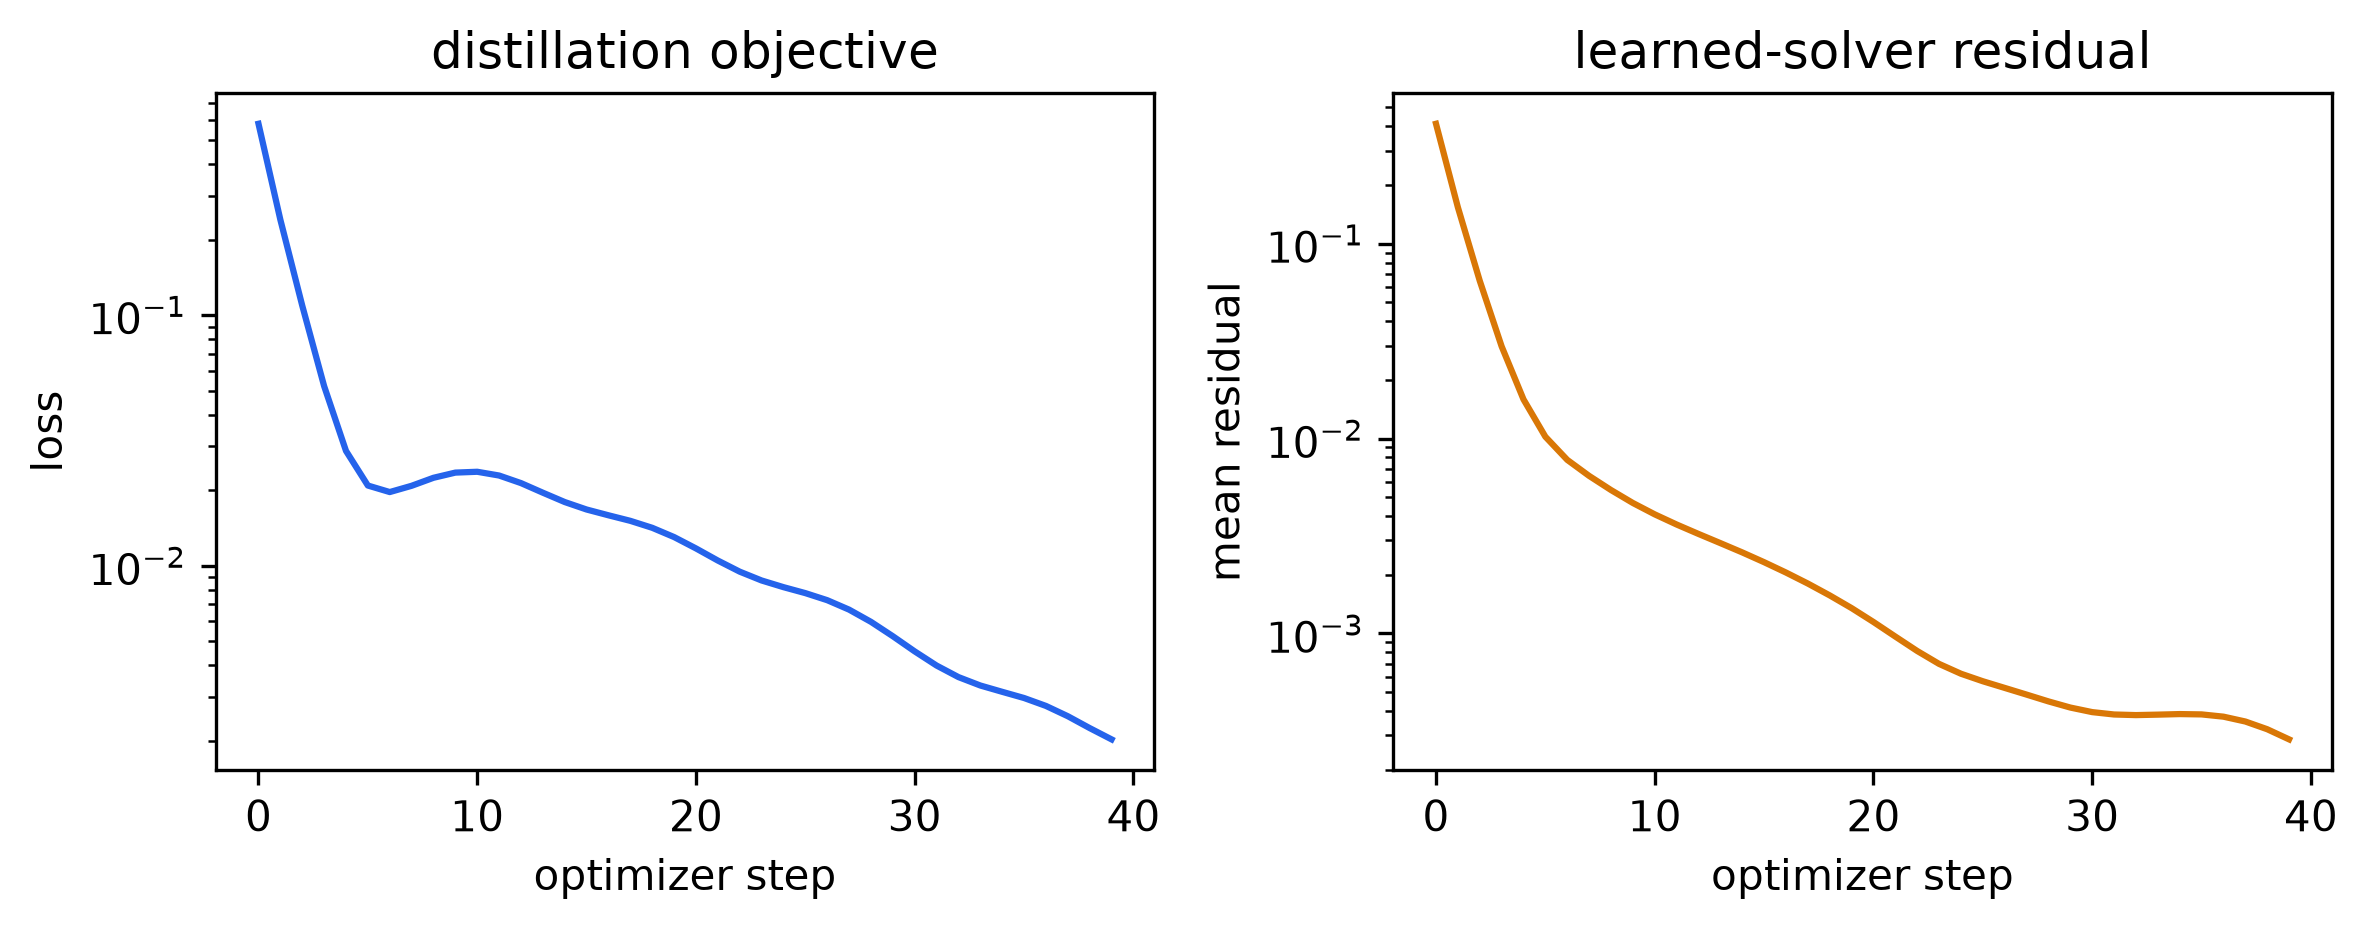

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
axes[0].plot(loss_curve, color="#2563eb")
axes[0].set(title="distillation objective", xlabel="optimizer step", ylabel="loss")
axes[0].set_yscale("log")
axes[1].plot(residual_curve, color="#d97706")
axes[1].set(title="learned-solver residual", xlabel="optimizer step", ylabel="mean residual")
axes[1].set_yscale("log")
fig.tight_layout()
plt.show()

## 3. Inspect the Learned Trajectory

A fast task metric is not enough. We also inspect every state error, residual,
coefficient vector, and mixing value.

In [5]:
for index, state in enumerate(trained.states):
    rmse = torch.mean((state - teacher.z).square()).sqrt()
    alpha = trained.coefficients[index]
    beta = trained.mixing[index]
    print(
        f"step {index + 1}: rmse={float(rmse):.6f} "
        f"residual={float(trained.residuals[index].mean()):.6f} "
        f"alpha_sum={float(alpha[0].sum()):.6f} beta={float(beta.mean()):.4f}"
    )

step 1: rmse=0.005197 residual=0.129943 alpha_sum=1.000000 beta=0.9376
step 2: rmse=0.001122 residual=0.012885 alpha_sum=1.000000 beta=0.9378
step 3: rmse=0.000590 residual=0.002404 alpha_sum=1.000000 beta=0.9379
step 4: rmse=0.000437 residual=0.001171 alpha_sum=1.000000 beta=0.9379
step 5: rmse=0.000147 residual=0.000858 alpha_sum=1.000000 beta=0.9345


## 4. Replace the Vector Transition With a Field Architecture

The state contract is $B\times C\times H\times W$. The controller still sees
compressed residuals shaped $B\times d_r$, so no solver code changes.

In [6]:
from torch import nn

class FieldTransition(nn.Module):
    def __init__(self):
        super().__init__()
        self.state = nn.Conv2d(2, 2, 3, padding=1, bias=False)
        self.source = nn.Conv2d(1, 2, 1)

    def forward(self, z, x):
        return torch.tanh(0.08 * self.state(z) + self.source(x))

class FieldInitializer(nn.Module):
    def forward(self, x):
        return torch.zeros(x.shape[0], 2, x.shape[2], x.shape[3], device=x.device)

field_model = SILVAHyperDEQ(
    state_shape=(2, 8, 8),
    condition_dim=1,
    transition=FieldTransition(),
    initializer=FieldInitializer(),
    learned_steps=3,
    history=3,
)
field_condition = torch.randn(3, 1, 8, 8)
field_result = field_model(field_condition)
field_result.state.square().mean().backward()
print("field state:", field_result.state.shape)
print("field output:", field_result.output.shape)
print("transition gradient norm:", float(field_model.transition.state.weight.grad.norm()))

field state: torch.Size([3, 2, 8, 8])
field output: torch.Size([3, 2, 8, 8])
transition gradient norm: 0.0026812059804797173


## 5. Source-Scale Route

### Source-Scale Reproduction Route

The source study uses trained DEQ transitions on WikiText-103, ImageNet, and
Cityscapes. Reproduce the base checkpoint first, generate high-precision teacher
roots with the declared solver budget, train the initializer/controller on
cached trajectories, and report both task quality and wall-clock latency. Keep
sequence length, image resolution, batching, solver tolerance, and hardware
fixed across the classical and learned solvers [[65]] [[67]].

In [7]:
from silva_networks import silva_reproduction_spec

spec = silva_reproduction_spec("silva_hyper_deq")
print("equation:", spec.equation)
print("datasets:", spec.datasets)
print("repositories:", spec.repositories)
print("configurable parts:")
for item in spec.configurable_parts:
    print(" -", item)
print("benchmark obligations:")
for item in spec.benchmark_requirements:
    print(" -", item)

equation: z_0=h_phi(x); alpha_k,beta_k=H_phi(r_(k-m+1:k),x); z_(k+1)=beta_k sum_i alpha_(k,i) f(z_i,x)+(1-beta_k) sum_i alpha_(k,i) z_i
datasets: ('WikiText-103', 'ImageNet', 'Cityscapes', 'compact contractive teacher trajectories')
repositories: ('https://github.com/locuslab/deq',)
configurable parts:
 - replace the transition, initializer, residual compressor, controller, or readout
 - train the solver around a frozen task model or jointly with the SILVA transition
 - teacher trajectory cache
 - learned solver steps
 - residual history
 - compressor and controller width
benchmark obligations:
 - source task model/checkpoint, teacher solver budget, training split, latency protocol, and task metric


## From 48 Silva Learned Solvers to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the latent vector or tensor z |
| Condition | the injected observation x |
| Repeated computation | the tied map f_theta(z, x) |
| Required invariants | state shape and a decreasing or bounded residual |
| Replaceable components | transition, damping, stopping rule, backward solver, and readout |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [8]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**distance to an analytic fixed point and final relative residual**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **latent width, solver tolerance, and iteration budget**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [9]:
notebook_reproduction_record = {
    "notebook": '48_silva_learned_solvers.ipynb',
    "state": 'the latent vector or tensor z',
    "condition": 'the injected observation x',
    "transition": 'the tied map f_theta(z, x)',
    "invariants": 'state shape and a decreasing or bounded residual',
    "compact_metric": 'distance to an analytic fixed point and final relative residual',
    "scale_axis": 'latent width, solver tolerance, and iteration budget',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '48_silva_learned_solvers.ipynb',
 'state': 'the latent vector or tensor z',
 'condition': 'the injected observation x',
 'transition': 'the tied map f_theta(z, x)',
 'invariants': 'state shape and a decreasing or bounded residual',
 'compact_metric': 'distance to an analytic fixed point and final relative residual',
 'scale_axis': 'latent width, solver tolerance, and iteration budget'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the latent vector or tensor z**, and its repeated map,
**the tied map f_theta(z, x)**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [10]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


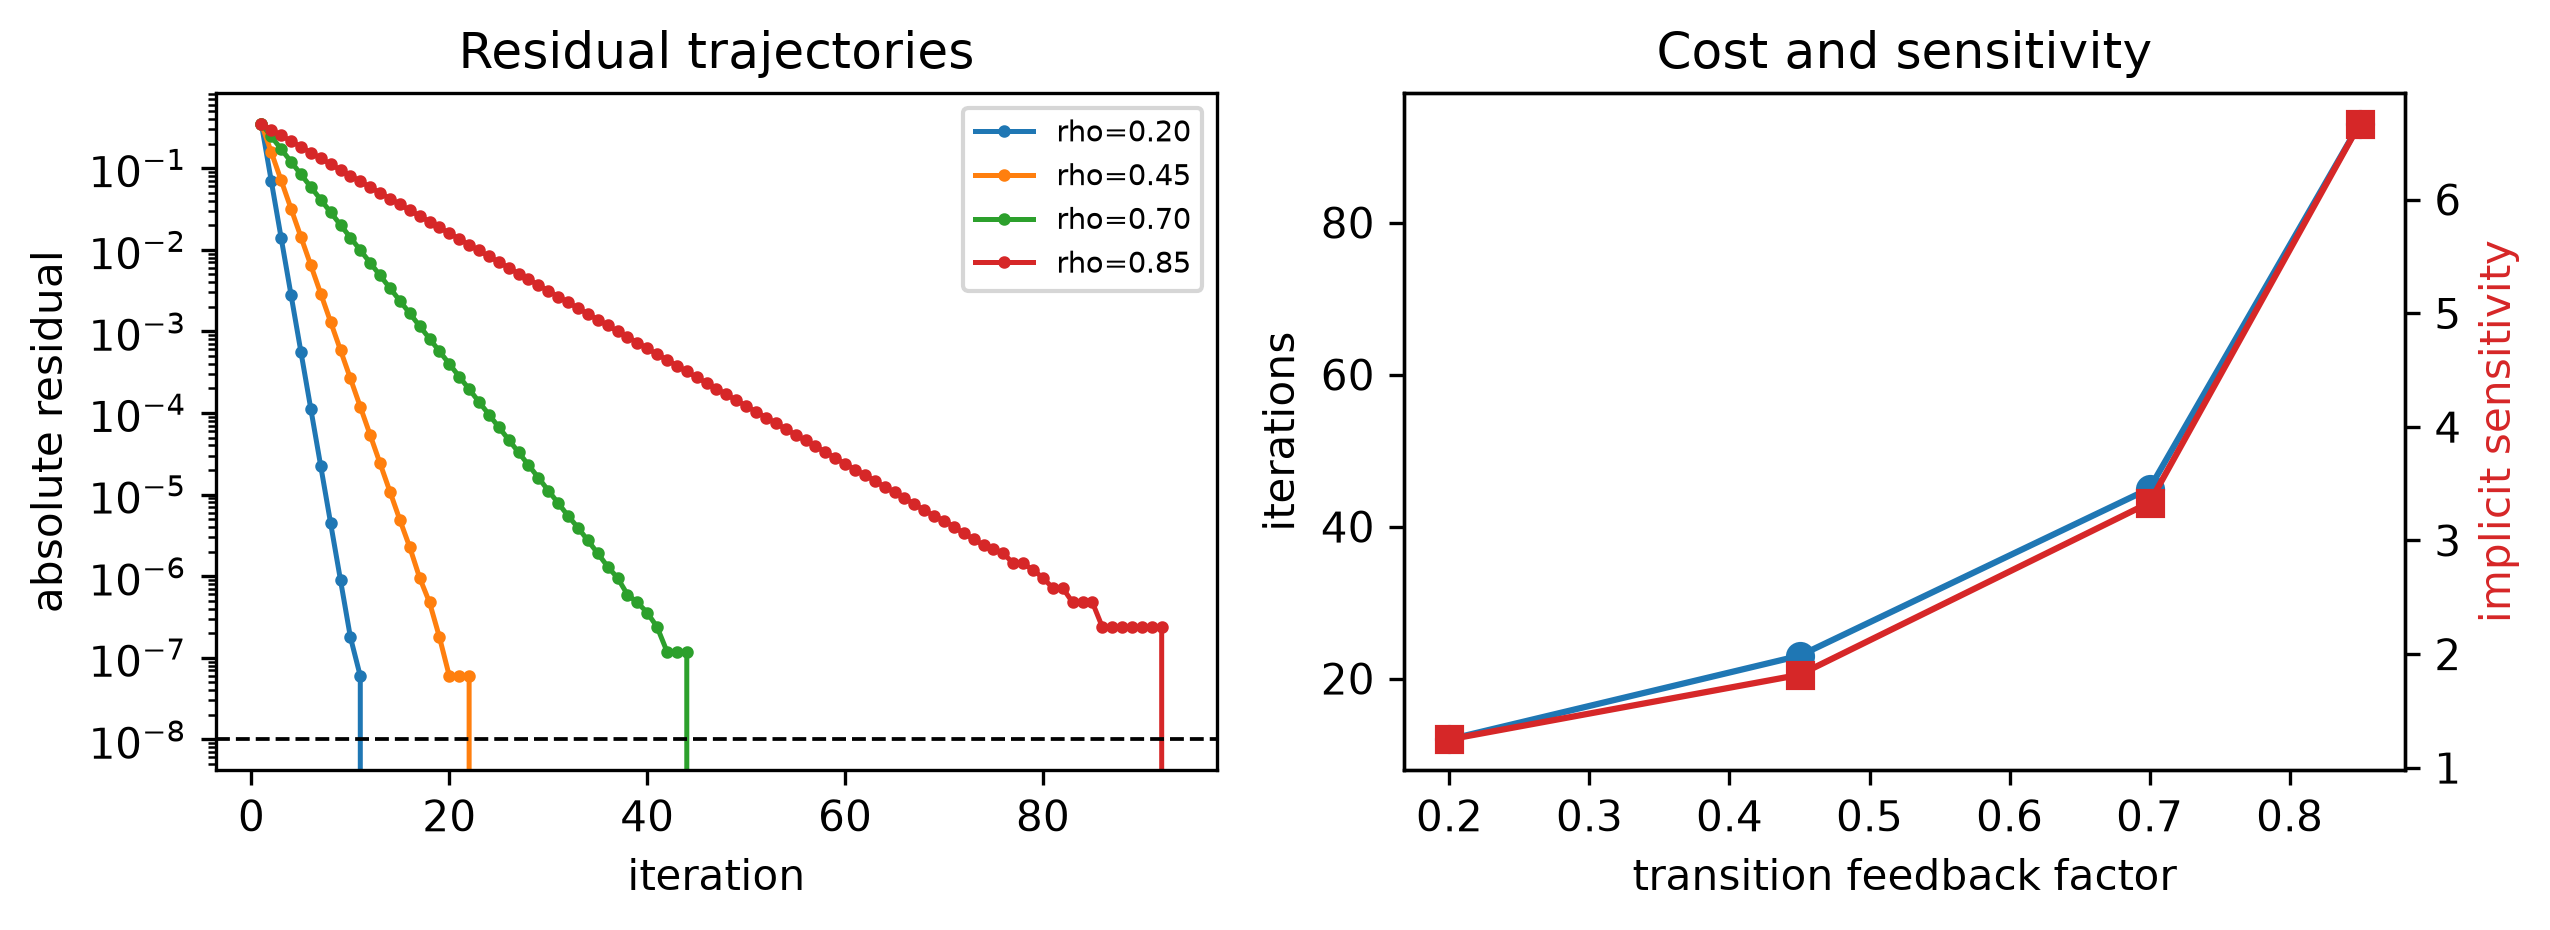

In [11]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | distance to an analytic fixed point and final relative residual |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | state shape and a decreasing or bounded residual |
| Scale sweep | Change one of latent width, solver tolerance, and iteration budget at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How are learned Anderson updates and losses derived? | [Learned Solvers and Backward Approximations](https://jseluis.github.io/silva-networks/learn/solver-learning-and-gradients/) |
| Where is the complete executable script? | [Learned Solver Example](https://jseluis.github.io/silva-networks/examples/learned-solvers/) |
| Which learned-solver objects are public? | [Learned Solver API](https://jseluis.github.io/silva-networks/api/solver_learning/) |
